# Astrophotography Image Denoising using Deep Learning

### In this notebook we will analyze the denoised FITS files produced by our ML models (N2V and N2N). We will extract SNR, CNR, and FWHM metrics and visualize the results.

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from importlib import reload
import utils
reload(utils)
from utils import do_aperture_photometry
from skimage.feature import peak_local_max

## Loading Data from FITS files

#### Here we load the denoised n2n and n2v files from the directory 'Denoised_Science', which we will then make two dataframes (n2n and n2v) which will include:

1. SNR (Signal-to-Noise Ratio)
2. CNR (Contrast-to-Noise Ratio)
3. FWHM (Full-Width-Half-Maximum)

#### We will also make a dataframe for the calibrated data to be used as our baseline.

In [2]:
# Grab denoised files from N2V and N2N models
n2v_files = np.load('LPSEB_registered_N2V.npy')
n2n_files = np.load('LPSEB_registered_N2N.npy')

print(f'N2V file has shape {n2v_files.shape}.')
print(f'N2N file has shape {n2n_files.shape}.')

# Grab calibrated science files for baseline comparison
noisy_files = np.load('LPSEB_registered.npy')
print(f'Noisy file has shape {noisy_files.shape}.')

N2V file has shape (100, 800, 800).
N2N file has shape (100, 800, 800).
Noisy file has shape (100, 800, 800).


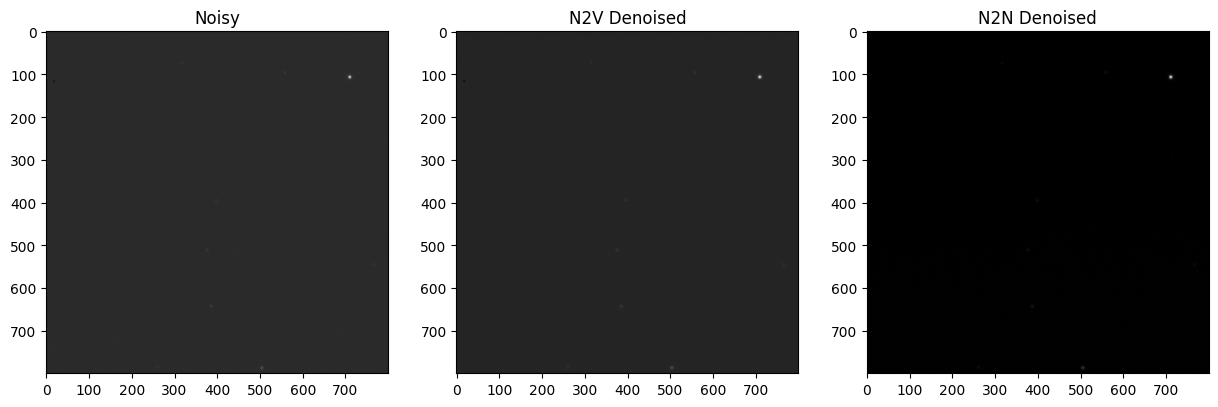

In [3]:
# View denoised files
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(noisy_files[0], cmap='gray')
ax[0].set_title('Noisy')
ax[1].imshow(n2v_files[0], cmap='gray')
ax[1].set_title('N2V Denoised')
ax[2].imshow(n2n_files[0], cmap='gray')
ax[2].set_title('N2N Denoised');

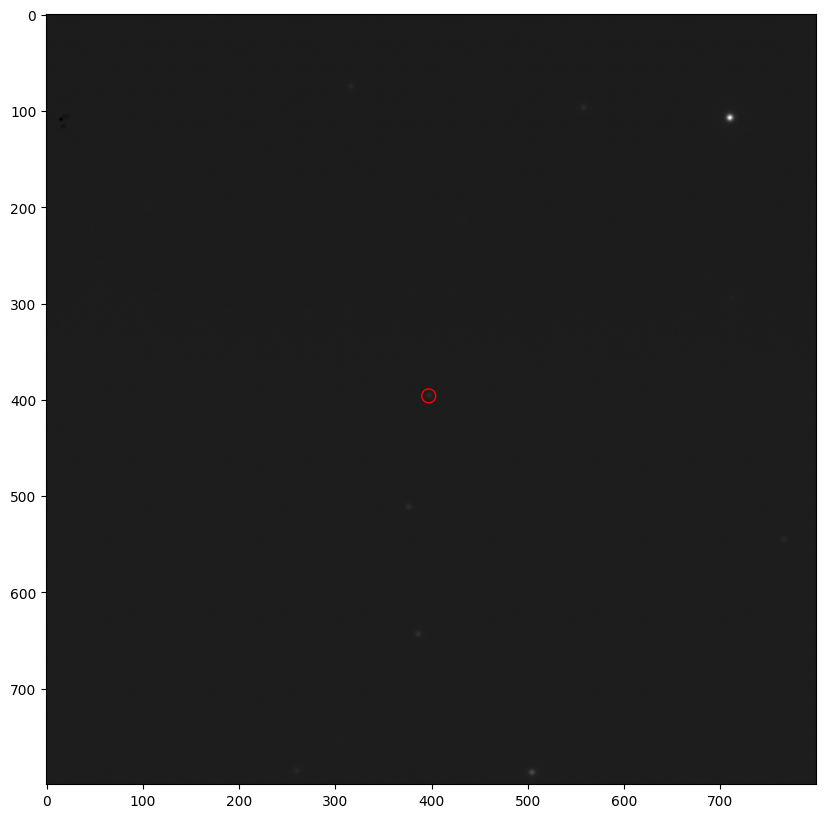

In [4]:
# Define mask where LPSEB30 is located
mask = np.zeros_like(noisy_files[0], dtype=bool)
mask[300:400, 350:450] = True

peak = peak_local_max(np.mean(noisy_files, axis=0), num_peaks=1, labels=mask)

# Plot location of peak
plt.figure(figsize=(10, 10))
plt.imshow(np.mean(noisy_files, axis=0), cmap='gray')
plt.scatter(peak[:, 1], peak[:, 0], marker='o', color='red', s=100, facecolors='none');

## Extracting Metrics

### Now we can extract the three metrics from each file and populate the dataframes.

In [6]:
def extract_metrics(data: np.ndarray, peak: np.ndarray) -> tuple:
    """
    Extract SNR, CNR, and FWHM from a denoised FITS file.

    Parameters
    ----------
    data: ndarray
          2D array of the FITS image data.
    peak: ndarray
          2D array of the peak coordinates (y, x).

    Returns
    -------
    SNR:  float
          Signal-to-noise ratio.
    CNR:  float
          Contrast-to-noise ratio.
    FWHM: float
          Full width at half maximum.
    """

    position = (peak[0][1], peak[0][0])

    # Photometry parameters inferred by first looking at data and then testing
    photometry_radius = 12
    annulus_radius    = 18
    annulus_width     = 4

    # Use custom function to compute SNR, CNR, FWHM; see utils.py
    snr, cnr, fwhm = do_aperture_photometry(data, position, photometry_radius, annulus_radius, annulus_width)

    return snr, cnr, fwhm

In [7]:
n2n_data = []
n2v_data = []
noisy_data = []

for n2n_file in n2n_files:

    n2n_metrics = extract_metrics(n2n_file, peak)
    if n2n_metrics is None:
        continue
    snr, cnr, fwhm = n2n_metrics
    n2n_data.append([snr, cnr, fwhm])
    
for n2v_file in n2v_files:
    n2v_metrics = extract_metrics(n2v_file, peak)
    if n2v_metrics is None:
        continue
    snr, cnr, fwhm = n2v_metrics
    n2v_data.append([snr, cnr, fwhm])

for noisy_file in noisy_files:
    noisy_metrics = extract_metrics(noisy_file, peak)
    if noisy_metrics is None:
        continue
    snr, cnr, fwhm = noisy_metrics
    noisy_data.append([snr, cnr, fwhm])

n2n_df = pd.DataFrame(n2n_data, columns=['snr', 'cnr', 'fwhm'])
n2v_df = pd.DataFrame(n2v_data, columns=['snr', 'cnr', 'fwhm'])
noisy_df = pd.DataFrame(noisy_data, columns=['snr', 'cnr', 'fwhm'])

print("N2N DataFrame:")
print('SNR Mean:', n2n_df['snr'].mean())
print('SNR σ:', n2n_df['snr'].std())        
display(n2n_df.head())

print("N2V DataFrame:")
print('SNR Mean:', n2v_df['snr'].mean())
print('SNR σ:', n2v_df['snr'].std())
display(n2v_df.head())

print("Noisy DataFrame:")
print('SNR Mean:', noisy_df['snr'].mean())
print('SNR σ:', noisy_df['snr'].std())
display(noisy_df.head())

N2N DataFrame:
SNR Mean: 60.34465563724659
SNR σ: 8.653342146935092


,snr,cnr,fwhm
0,61.715184,4760.373785,7.706475
1,60.719223,5061.141864,7.822921
2,54.606716,4473.151426,8.142737
3,48.632003,4696.011884,11.483267
4,45.332136,3368.247167,11.349228


N2V DataFrame:
SNR Mean: 48.282416709976886
SNR σ: 6.795124005338022


,snr,cnr,fwhm
0,48.705251,4314.407572,7.396739
1,48.131564,4601.190784,7.487709
2,43.156072,3929.951365,7.829713
3,38.976770,4432.841122,10.935217
4,36.254558,3041.485474,10.777122


Noisy DataFrame:
SNR Mean: 44.62557745616939
SNR σ: 6.925213547557243


,snr,cnr,fwhm
0,44.560024,1885.060394,6.018292
1,44.002438,1960.716467,5.980076
2,39.468719,1623.843540,6.353640
3,35.043224,1426.244205,9.129614
4,32.757298,1295.388662,8.741450


## Analysis

#### Now that the dataframes are populated, we can proceed with the analysis. We will analyze the distributions for SNR, CNR, and FWHM and determine if there was an improvement!

### SNR

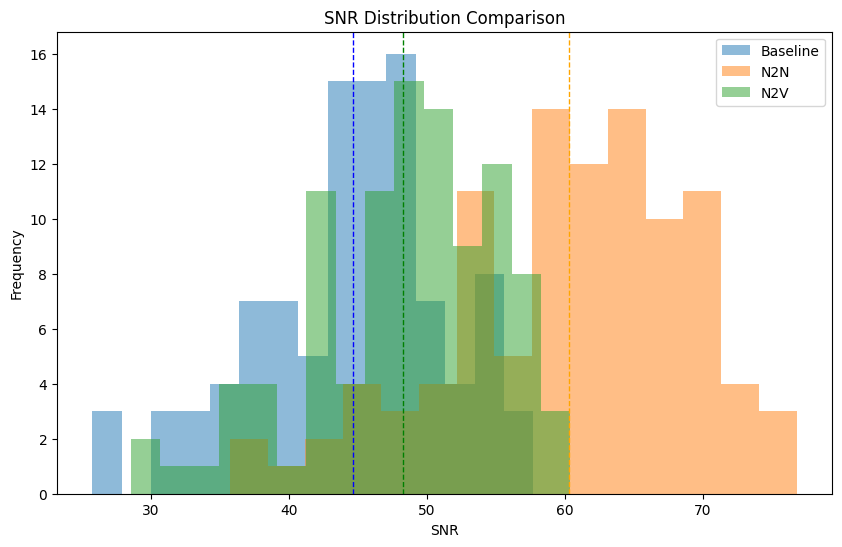

In [8]:
# Compare SNR distributions between N2N and N2V, using the calibrated data as our baseline.

plt.figure(figsize=(10, 6))
plt.hist(noisy_df['snr'], bins=15, alpha=0.5, label='Baseline')
plt.hist(n2n_df['snr'], bins=15, alpha=0.5, label='N2N')
plt.hist(n2v_df['snr'], bins=15, alpha=0.5, label='N2V')

# Vertical lines for means
plt.axvline(noisy_df['snr'].mean(), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(n2n_df['snr'].mean(), color='orange', linestyle='dashed', linewidth=1)
plt.axvline(n2v_df['snr'].mean(), color='green', linestyle='dashed', linewidth=1)

# Labels and legend
plt.xlabel('SNR')
plt.ylabel('Frequency')
plt.title('SNR Distribution Comparison')
plt.legend();

### CNR

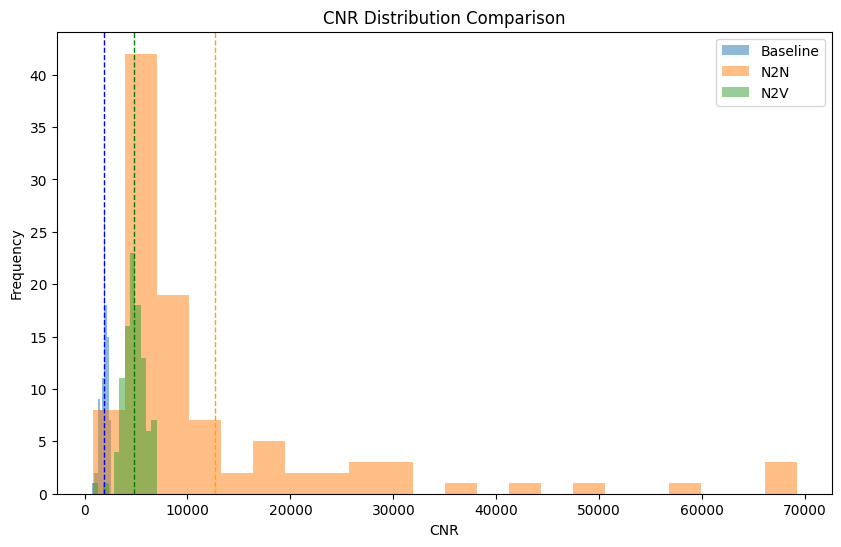

In [9]:
# Compare CNR distributions between N2N and N2V, using the calibrated data as our baseline.
plt.figure(figsize=(10, 6))
plt.hist(noisy_df['cnr'], bins='fd', alpha=0.5, label='Baseline')
plt.hist(n2n_df['cnr'], bins='fd', alpha=0.5, label='N2N')
plt.hist(n2v_df['cnr'], bins='fd', alpha=0.5, label='N2V')

# Vertical lines for means
plt.axvline(noisy_df['cnr'].mean(), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(n2n_df['cnr'].mean(), color='orange', linestyle='dashed', linewidth=1)
plt.axvline(n2v_df['cnr'].mean(), color='green', linestyle='dashed', linewidth=1)

# Labels and legend
plt.xlabel('CNR')
plt.ylabel('Frequency')
plt.title('CNR Distribution Comparison')
plt.legend();

### FWHM

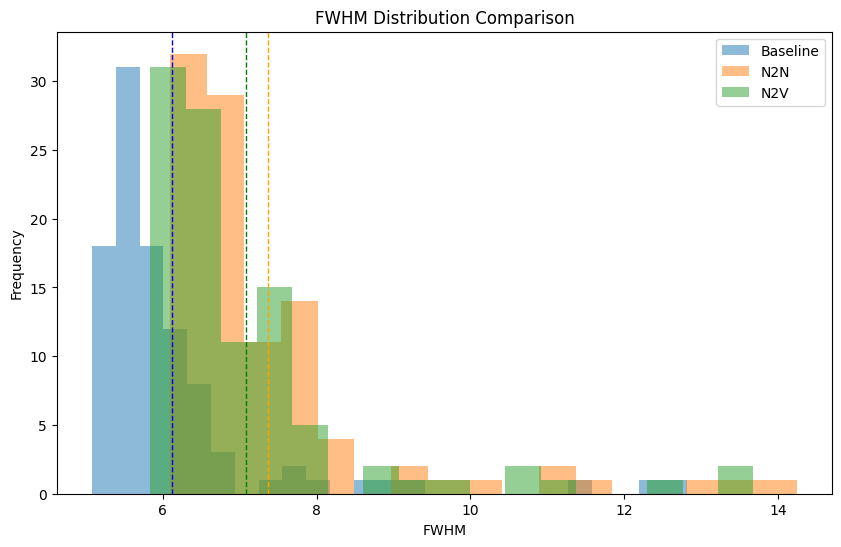

In [10]:
# Compare FWHM distributions between N2N and N2V, using the calibrated data as our baseline.
plt.figure(figsize=(10, 6))
plt.hist(noisy_df['fwhm'], bins='fd', alpha=0.5, label='Baseline')
plt.hist(n2n_df['fwhm'], bins='fd', alpha=0.5, label='N2N')
plt.hist(n2v_df['fwhm'], bins='fd', alpha=0.5, label='N2V')

# Vertical lines for means
plt.axvline(noisy_df['fwhm'].mean(), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(n2n_df['fwhm'].mean(), color='orange', linestyle='dashed', linewidth=1)
plt.axvline(n2v_df['fwhm'].mean(), color='green', linestyle='dashed', linewidth=1)

# Labels and legend
plt.xlabel('FWHM')
plt.ylabel('Frequency')
plt.title('FWHM Distribution Comparison')
plt.legend();

As seen above, both n2n and n2v increase FWHM, which is unwanted in astrophotography since we want sharper edges to distinguish between noise and signal.

## Residuals

#### We want to verify that the residuals of each denoised frame is ~ Guassian to ensure it is removing noise and not signal.

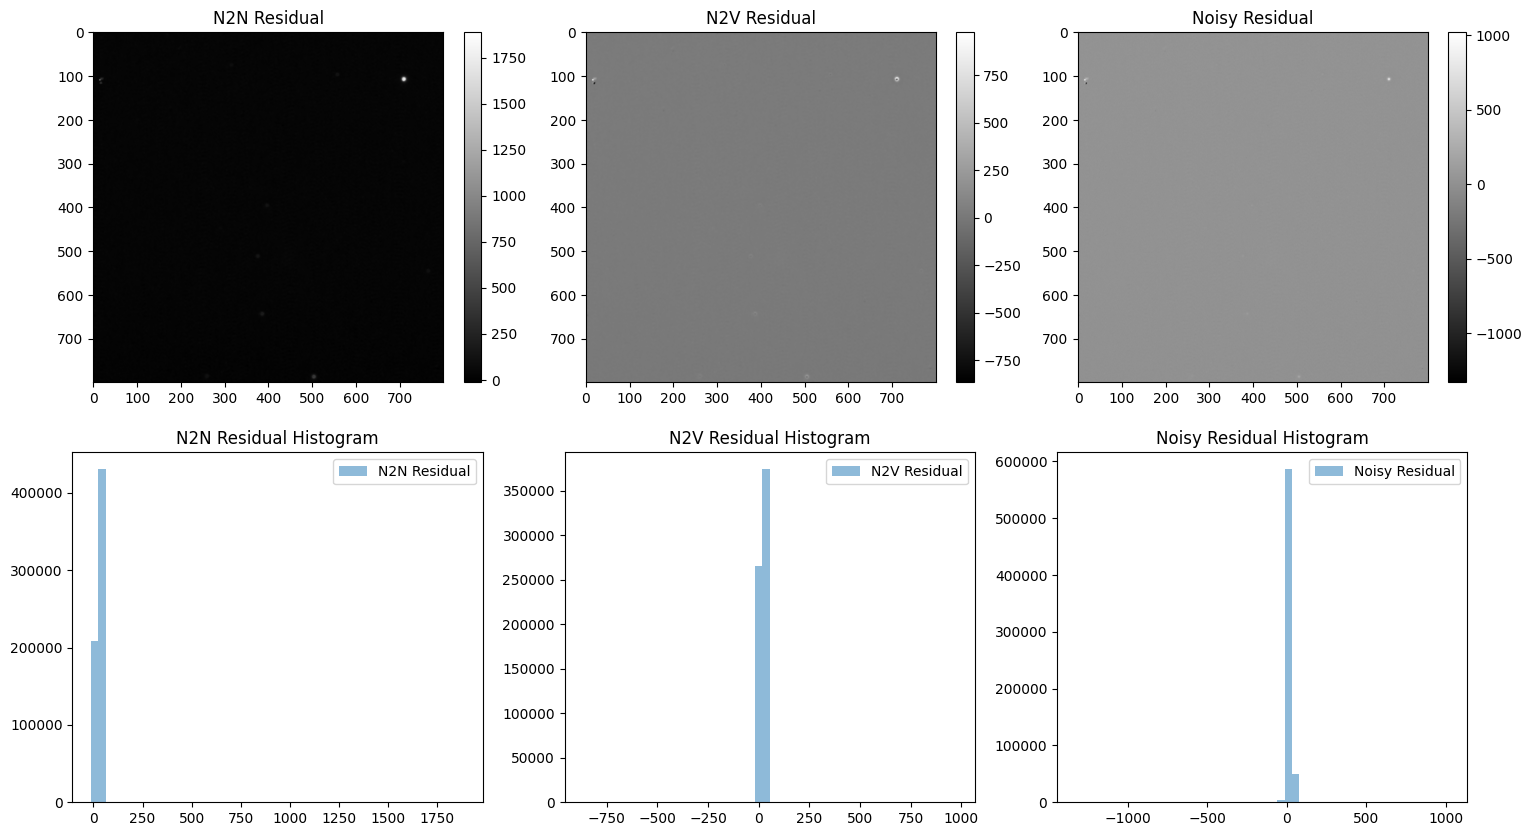

In [11]:
noisy_residual = noisy_files[0] - np.mean(noisy_files, axis=0)
n2n_residual = n2n_files[0] - np.mean(noisy_files, axis=0)
n2v_residual = n2v_files[0] - np.mean(noisy_files, axis=0)


# Plot the 3 residuals on the same colormap scale
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

im1 = axs[0, 0].imshow(n2n_residual, cmap='gray')
axs[0, 0].set_title('N2N Residual')
fig.colorbar(im1, ax=axs[0, 0], fraction=0.046, pad=0.05)

im2 = axs[0, 1].imshow(n2v_residual, cmap='gray')
axs[0, 1].set_title('N2V Residual')
fig.colorbar(im2, ax=axs[0, 1], fraction=0.046, pad=0.05)

im3 = axs[0, 2].imshow(noisy_residual, cmap='gray')
axs[0, 2].set_title('Noisy Residual')
fig.colorbar(im3, ax=axs[0, 2], fraction=0.046, pad=0.05)

# Plot histogram of residuals for N2N and N2V
im4 = axs[1, 0].hist(n2n_residual.flatten(), bins=50, alpha=0.5, label='N2N Residual')
axs[1, 0].set_title('N2N Residual Histogram')
axs[1, 0].legend()

im5 = axs[1, 1].hist(n2v_residual.flatten(), bins=50, alpha=0.5, label='N2V Residual')
axs[1, 1].set_title('N2V Residual Histogram')
axs[1, 1].legend()

im6 = axs[1, 2].hist(noisy_residual.flatten(), bins=50, alpha=0.5, label='Noisy Residual')
axs[1, 2].set_title('Noisy Residual Histogram')
axs[1, 2].legend();

### There seems to be systematic artifacts that are not from the models, but the images themselves... Let's take a patch of the residuals where the artifact isn't there.

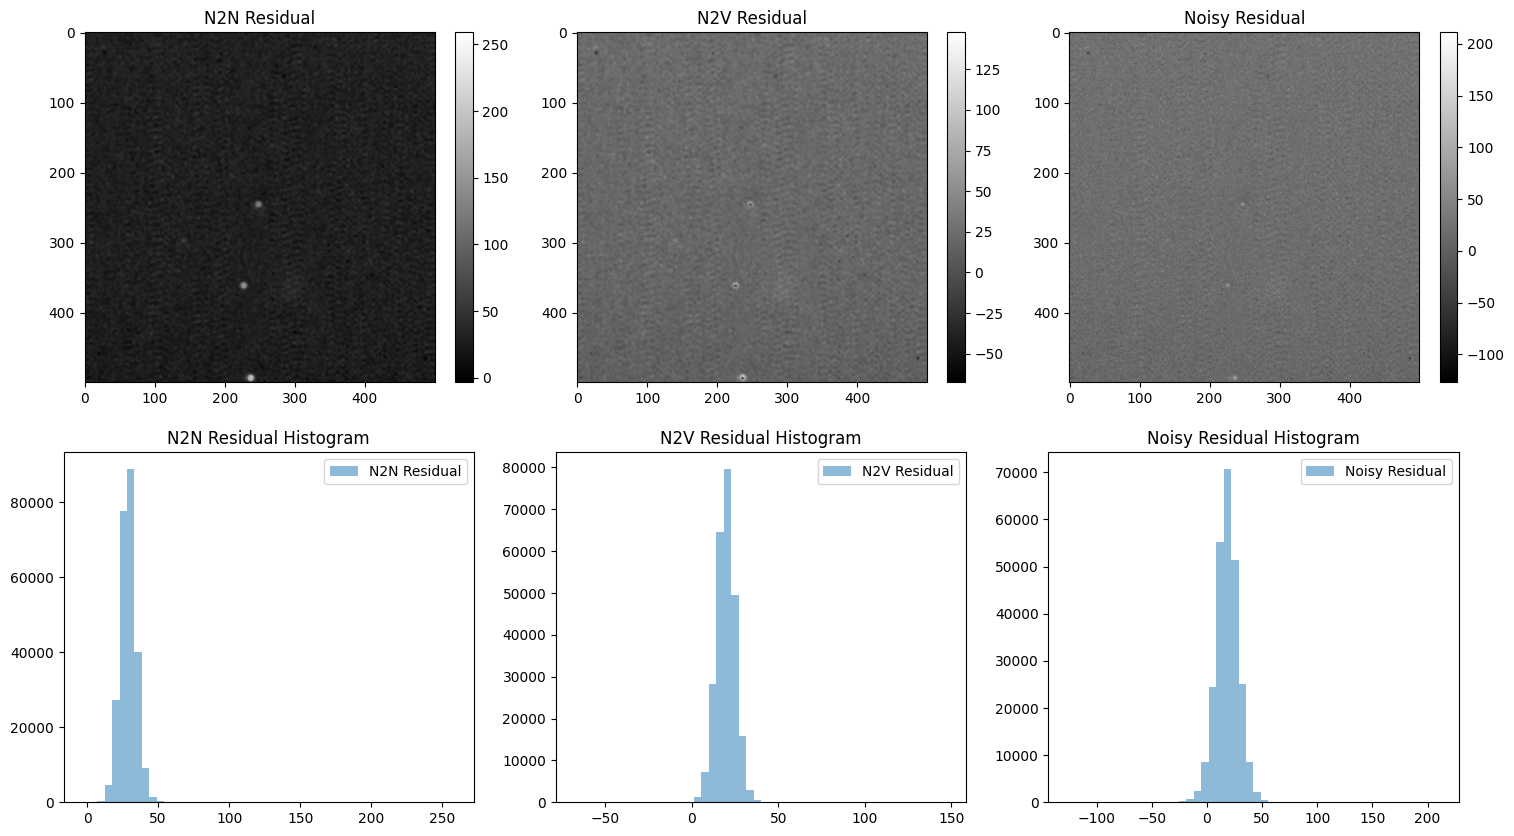

In [12]:
noisy_residual = noisy_files[0] - np.mean(noisy_files, axis=0)
n2n_residual = n2n_files[0] - np.mean(noisy_files, axis=0)
n2v_residual = n2v_files[0] - np.mean(noisy_files, axis=0)

# slice each residual to a 500x500 center patch where the artifact isn't present
H, W = noisy_residual.shape
center_h, center_w = H // 2, W // 2
half_patch_size = 250
n2n_residual = n2n_residual[center_h - half_patch_size:center_h + half_patch_size, center_w - half_patch_size:center_w + half_patch_size]
n2v_residual = n2v_residual[center_h - half_patch_size:center_h + half_patch_size, center_w - half_patch_size:center_w + half_patch_size]
noisy_residual = noisy_residual[center_h - half_patch_size:center_h + half_patch_size, center_w - half_patch_size:center_w + half_patch_size]

# Plot the 3 residuals on the same colormap scale
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

im1 = axs[0, 0].imshow(n2n_residual, cmap='gray')
axs[0, 0].set_title('N2N Residual')
fig.colorbar(im1, ax=axs[0, 0], fraction=0.046, pad=0.05)

im2 = axs[0, 1].imshow(n2v_residual, cmap='gray')
axs[0, 1].set_title('N2V Residual')
fig.colorbar(im2, ax=axs[0, 1], fraction=0.046, pad=0.05)

im3 = axs[0, 2].imshow(noisy_residual, cmap='gray')
axs[0, 2].set_title('Noisy Residual')
fig.colorbar(im3, ax=axs[0, 2], fraction=0.046, pad=0.05)

# Plot histogram of residuals for N2N and N2V
im4 = axs[1, 0].hist(n2n_residual.flatten(), bins=50, alpha=0.5, label='N2N Residual')
axs[1, 0].set_title('N2N Residual Histogram')
axs[1, 0].legend()

im5 = axs[1, 1].hist(n2v_residual.flatten(), bins=50, alpha=0.5, label='N2V Residual')
axs[1, 1].set_title('N2V Residual Histogram')
axs[1, 1].legend()

im6 = axs[1, 2].hist(noisy_residual.flatten(), bins=50, alpha=0.5, label='Noisy Residual')
axs[1, 2].set_title('Noisy Residual Histogram')
axs[1, 2].legend();

## Auto correlation

#### We want to check the auto-correlation between the residuals for each model and ensure that random noise is being filtered out as we don't want to introduce systematic errors.

#### We should expect high correlation for signals (i.e. stars) between the images and very little to no correlation for noisy regions.

In [13]:
# Check auto correlation of residuals
def autocorr2d(image):
    """
    Compute the 2D autocorrelation of an image.
    
    Parameters
    ----------
    image: ndarray
          2D array of the FITS image data.

    Returns
    -------
    autocorr: ndarray
              2D array of the autocorrelation.
    """
    # Subtract mean to remove DC component
    image -= np.mean(image)
    
    # FFT
    f = np.fft.fft2(image)
    
    # Power spectrum (magnitude squared)
    power = f * np.conj(f)
    
    # Inverse FFT to get autocorrelation
    autocorr = np.fft.ifft2(power).real
    
    # Shift zero-lag to center
    autocorr = np.fft.fftshift(autocorr)
    
    # Normalize (optional but common)
    autocorr /= np.max(autocorr)
    
    return autocorr

# We can take the mean of the noisy files to be ~ ground truth
noisy_autocorr = autocorr2d(noisy_residual)
n2n_autocorr = autocorr2d(n2n_residual)
n2v_autocorr = autocorr2d(n2v_residual)

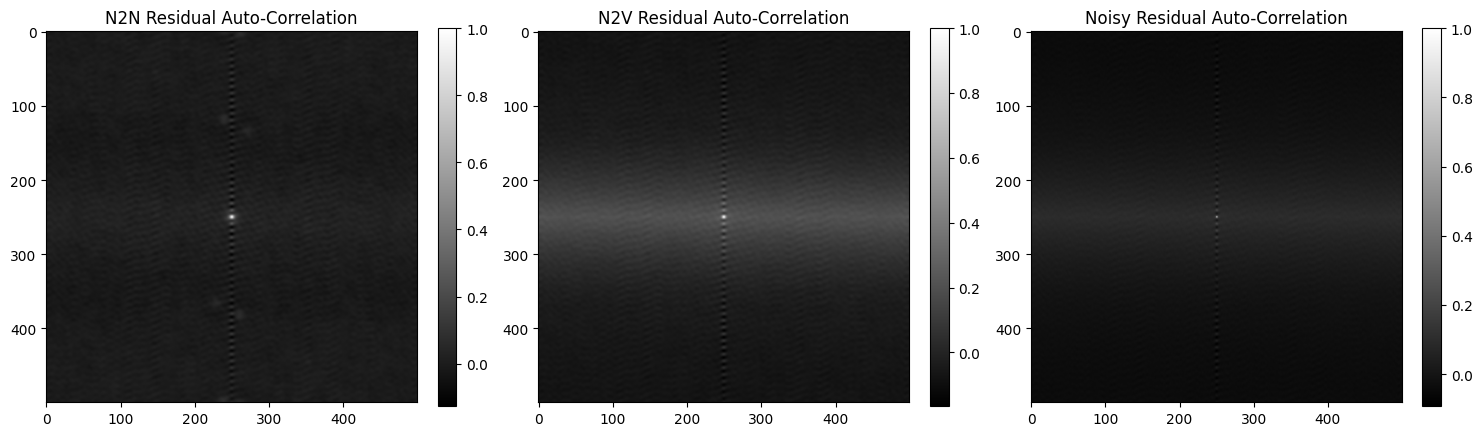

In [14]:
# Plot the 2 auto-correlations on the same colormap scale
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

im1 = axs[0].imshow(n2n_autocorr, cmap='gray')
axs[0].set_title('N2N Residual Auto-Correlation')
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.05)

im2 = axs[1].imshow(n2v_autocorr, cmap='gray')
axs[1].set_title('N2V Residual Auto-Correlation')
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.05)

im3 = axs[2].imshow(noisy_autocorr, cmap='gray')
axs[2].set_title('Noisy Residual Auto-Correlation')
fig.colorbar(im3, ax=axs[2], fraction=0.046, pad=0.05);

### There seems to be correlation for the noisy residual to begin with...

### Given this, the auto correlation of the residual may not be the best measure since there may be leftover systematic noise.

## Results and Key Takeaways

### Quantifying improvement from models.

In [17]:
# Since we have SNR, CNR, and FWHM data for all three methods (baseline, N2N, N2V), we can quantify the improvement each model provides.
# We can compute the percentage improvement in SNR and CNR, and the percentage increase in FWHM for each model compared to the baseline.
snr_improvement_n2n = ((n2n_df['snr'] - noisy_df['snr']) / noisy_df['snr']) * 100
snr_improvement_n2v = ((n2v_df['snr'] - noisy_df['snr']) / noisy_df['snr']) * 100
cnr_improvement_n2n = ((n2n_df['cnr'] - noisy_df['cnr']) / noisy_df['cnr']) * 100
cnr_improvement_n2v = ((n2v_df['cnr'] - noisy_df['cnr']) / noisy_df['cnr']) * 100
fwhm_increase_n2n = ((n2n_df['fwhm'] - noisy_df['fwhm']) / noisy_df['fwhm']) * 100
fwhm_increase_n2v = ((n2v_df['fwhm'] - noisy_df['fwhm']) / noisy_df['fwhm']) * 100

# Display average improvements
print("Average SNR Improvement:")
print("N2N: {:.2f}%".format(snr_improvement_n2n.mean()))
print("N2V: {:.2f}%".format(snr_improvement_n2v.mean()))

print("Average CNR Improvement:")
print("N2N: {:.2f}%".format(cnr_improvement_n2n.mean()))
print("N2V: {:.2f}%".format(cnr_improvement_n2v.mean()))

print("Average FWHM Increase:")
print("N2N: {:.2f}%".format(fwhm_increase_n2n.mean()))
print("N2V: {:.2f}%".format(fwhm_increase_n2v.mean()))

Average SNR Improvement:
N2N: 35.56%
N2V: 8.48%
Average CNR Improvement:
N2N: 511.93%
N2V: 151.96%
Average FWHM Increase:
N2N: 20.47%
N2V: 15.78%


* Since higher FWHM indicates blurrier images, we want to minimize FWHM increase while maximizing SNR and CNR improvements.

* From the results, we can see that both N2N and N2V provide significant improvements in SNR and CNR compared to the baseline calibrated images.

* However, N2N seems to significantly outperform N2V in both SNR and CNR.

* Overall, the choice between N2N and N2V may depend on the specific requirements for SNR, CNR, and acceptable FWHM increase in the denoised images.